In [2]:
import pandas as pd
import networkx as nx 
from matplotlib import pyplot as plt
import numpy as np

In [25]:
edge_list = pd.read_csv(r"D:\commo\code\4_kumu_struct\edge_list.csv")
node1 = pd.read_csv(r"D:\commo\code\4_kumu_struct\node_list1.csv")
node2 = pd.read_csv(r"D:\commo\code\4_kumu_struct\node_list2.csv")
node3 = pd.read_csv(r"D:\commo\code\4_kumu_struct\node_list3.csv")
node1.head()

,Label,Type,Description,Tier,Commodity Type,Commodity Focus,Legal Name / ACRA UEN,HQ Country,Estimated Revenue,Headcount (Global),Trade Volume (Est.),Ownership Structure,Exchange,APAC offices
0,trafigura group,"trader, lender",Latest acquisition (after Sep 2025): Greenergy...,3,multi (>2 types),oil | petroleum | natural gas | LNG | metals |...,TRAFIGURA GROUP PTE. LTD. / 201017488D (record...,Singapore,Trafigura Group: 240.3 USD bn FY2025 (trafigur...,5011 (linkedin),approx. 462 million metric tons (2025 annual r...,private,NaN,"10 Collyer Quay, #29-01/05, Ocean Financial Ce..."
1,vitol asia,trader,"Its largest operations are in Geneva, Houston,...",3,multi (>2 types),crude oil | petroleum | LNG | natural gas | bi...,VITOL ASIA PTE LTD. / 199001917Z (recordowl),Switzerland,Turnover of $343 billion FY2025 (company website),1990 (linkedin),total energy trade volume: 605 million tonnes ...,private,NaN,128 BEACH ROAD #28-01 GUOCO MIDTOWN OFFICE SIN...
2,mercuria holdings,others,Mercuria Holdings (Singapore) Pte. Ltd. is a g...,3,multi (>2 types),energy | metals | soft/agricultural,MERCURIA HOLDINGS (SINGAPORE) PTE. LTD. / 2018...,Switzerland,$618.7 Million (zoom.info),1380 (linkedin),6M+ barrels of oil equivalent (BOE) per day (c...,private,NaN,"12 Marina View, #26-01, Asia Square Tower 2, S..."
3,gunvor singapore,trader,one of the world's largest independent commodi...,3,energy,crude oil | refined petroleum products | natur...,GUNVOR SINGAPORE PTE. LTD. / 200606959K (acra ...,Switzerland,US $144 billion (company website),1035 (linkedin),253 million MT (company website),private,NaN,"128 Beach Road, #29-01, Guoco Midtown Office, ..."
4,louis dreyfus company asia,trader,"LDC is purely agricultural, no energy commodit...",3,soft/agricultural,grains | oilseeds | coffee | cotton | sugar | ...,LOUIS DREYFUS COMPANY ASIA PTE. LTD. / 1993065...,Netherlands,Net Sales: US$ 53.2bn FY2025 (2025.12 LDC - In...,"13,359 (linkedin)",~100 million tonnes of products shipped annual...,private,NaN,12 MARINA BOULEVARD #33-03 MARINA BAY FINANCIA...


In [ ]:
node3.columns

In [26]:
node1.rename(columns={
    'Label':'label',
    'Type':'role',
    'Description':'description',
    'Tier':'tier',
    'Commodity Type':'commodity_type',
    'Commodity Focus':'commodity_focus',
    'Legal Name / ACRA UEN':'acra_uen',
    'HQ Country':'hq_country',
    'Estimated Revenue':'est_revenue',
    'Headcount (Global)':'global_headcount',
    'Trade Volume (Est.)':'est_trade_volume',
    'Ownership Structure':"ownership_struct",
    'Exchange':'exchange',
    'APAC offices':'sg_address'
}, inplace=True)
node2.rename(columns={
    'Label':'label',
    'Type':'role',
    'Description':'description',
    'Scope':'scope',
    'Office Location(s) in APAC':'sg_address',
    'Practice Areas':'practice_areas',
    'Known Client Base':'known_clients'
}, inplace=True)
node3.rename(columns={
    'Label':'label',
    'Type':'role',
    'Description':'description',
    'Financier Type':'financieir_type',
    'Commodity Type':'commodity_type',
    'Geographic Reach':'geographic_reach',
    'Known Clients':'known_clients'
}, inplace=True)

In [138]:
# create undirected graph
UG = nx.Graph()
# add all nodes
# add all nodes
records1 = node1.set_index("label").to_dict("index")
records2 = node2.set_index("label").to_dict("index")
records3 = node3.set_index("label").to_dict("index")
UG.add_nodes_from(records1.items())
UG.add_nodes_from(records2.items())
UG.add_nodes_from(records3.items())

# add edges
edges = [(row.From, row.To, {'type':row.Type}) for row in edge_list[['From','To','Type']].itertuples()]
UG.add_edges_from(edges)
# UG['trafigura group']['trafigura carbon trading'] > {'type':'owns'}

# community detection, run five times with different random seeds
run1 = nx.community.louvain_communities(UG, seed=123) # visualize
run2 = nx.community.louvain_communities(UG, seed=234)
run3 = nx.community.louvain_communities(UG, seed=345)
run4 = nx.community.louvain_communities(UG, seed=456)
run5 = nx.community.louvain_communities(UG, seed=567)

In [40]:
# create a directed graph
DG = nx.DiGraph()

# add all nodes
records1 = node1.set_index('label').to_dict('index')
records2 = node2.set_index("label").to_dict("index")
records3 = node3.set_index("label").to_dict("index")
DG.add_nodes_from(records1.items())
DG.add_nodes_from(records2.items())
DG.add_nodes_from(records3.items())

# add edges
edges = [(row.From, row.To, {'type':row.Type}) for row in edge_list[['From','To','Type']].itertuples()]
DG.add_edges_from(edges) # full edge list

# number of nodes and edges
no_nodes = nx.number_of_nodes(DG)
no_edges = nx.number_of_edges(DG)
print(no_nodes, no_edges)

# density
density_dg = nx.density(DG) # visualize

# degree-centrality, in-degree, out-degree
degree_centrality = nx.degree_centrality(DG) # visualize
in_degree_centrality = nx.in_degree_centrality(DG) # visualize
out_degree_centrality = nx.out_degree_centrality(DG) # visualize
# max(out_degree_centrality.items(), key=lambda x: x[1])

# betweenness centrality
betweenness_centrality = nx.betweenness_centrality(DG) # visualize

# pagerank v2 using networkx built-in function
print("Removing isolated nodes..")
all_nodes = list(DG.nodes())
# DG.edges({node}) shows all the edges, len(DG.edges({node})) shows the no of edges that node has
for node in all_nodes:
    if DG.in_degree(node) == 0 and DG.out_degree(node) == 0:
        DG.remove_node(node)
# labelling nodes as integers
print("Relabelling nodes to integers...")
# relabel nodes as integers
n_unique_nodes = len(set(DG.nodes()))  # 296 nodes total
# create dict{'label':int}
node2int = dict(zip(set(DG.nodes()), range(n_unique_nodes)))  # {'cofco international': 0,'hyundai corporation singapore': 1, etc}
# create an opp dict
int2node = {v: k for k, v in node2int.items()}  # {0: 'cofco international',1: 'hyundai corporation singapore', etc}
# relabel the directed graph with the node2int dict
DG = nx.relabel_nodes(DG, node2int)
pagerank_score = nx.pagerank(DG, alpha=0.8)
pagerank_score = nx.pagerank(DG, alpha=0.8)
ranked = sorted(pagerank_score.items(), key=lambda x: x[1], reverse=True)
for idx, score in ranked[:10]:
    print(int2node[idx], score)

296 169
Removing isolated nodes..
Relabelling nodes to integers...
trafigura group 0.02850901827973258
louis dreyfus company asia 0.019396810867691933
standard chartered bank singapore scb 0.012048739900261328
ed&f man capital markets singapore 0.011350281178122746
shell eastern trading 0.011001022041783147
mercuria energy trading 0.010023200673478347
cofco international singapore 0.009860193226339662
wilmar sugar 0.009851701547848025
petrochina international singapore 0.00960413437277629
unipec singapore 0.009487720863844404


In [29]:
# page rank v1 from scratch as backup, v2 .pagerank() primary result
# https://www.kaggle.com/code/rajat95gupta/implementing-pagerank-on-famous-social-networks

# pagerank v1 from scratch
def make_graph(DG):
    DG = DG.copy()
    # check if graph is directed
    print("Directed:", nx.is_directed(DG))
    # check if graph is weighted
    print("Weighted:", nx.is_weighted(DG))
    print()

    # converting to directed graph for pagerank
    if not nx.is_directed(DG):
        DG = DG.to_directed()

    print("Directed:", nx.is_directed(DG))
    print()

    print("Removing isolated nodes..")
    all_nodes = list(DG.nodes())
    # DG.edges({node}) shows all the edges, len(DG.edges({node})) shows the no of edges that node has
    for node in all_nodes:
        if DG.in_degree(node) == 0 and DG.out_degree(node) == 0:
            DG.remove_node(node)
    # labelling nodes as integers
    print("Relabelling nodes to integers...")
    # relabel nodes as integers
    n_unique_nodes = len(set(DG.nodes()))  # 296 nodes total
    # create dict{'label':int}
    node2int = dict(zip(set(DG.nodes()), range(n_unique_nodes)))  # {'cofco international': 0,'hyundai corporation singapore': 1, etc}
    # create an opp dict
    int2node = {v: k for k, v in node2int.items()}  # {0: 'cofco international',1: 'hyundai corporation singapore', etc}
    # relabel the directed graph with the node2int dict
    DG = nx.relabel_nodes(DG, node2int)
    return DG, int2node

def plot_graph(DG, final_probs, int2node, bool_final_probs=False):
    #defining labels
    labels = int2node
    
    if not bool_final_probs:
        nx.draw(DG, with_labels=True, alpha=0.8, arrows=False, labels=labels)
    else:
        nx.draw(DG, with_labels=True, alpha=0.8, arrows=False, node_color=final_probs, cmap=plt.get_cmap('viridis'), labels=labels)
        
        # adding color bar for pagerank importances
        sm = plt.cm.ScalarMappable(cmap=plt.get_cmap('viridis'), norm=plt.Normalize(vmin=min(final_probs), vmax=max(final_probs)))
        sm._A = []
        plt.colorbar(sm, ax=plt.gca())
    return plt

In [30]:
def make_pagerank_matrix(DG, alpha):
    n_nodes = len(DG.nodes())
    
    # build adjacent matrix
    adj_matrix = np.zeros(shape=(n_nodes, n_nodes)) #164x164 filled with 0s
    # fill in 1s
    for edge in DG.edges():
        adj_matrix[edge[0], edge[1]] = 1
        
    # build transition probability matrix
    row_sums = np.sum(adj_matrix, axis=1)
    tran_matrix = np.zeros_like(adj_matrix)
    nonzero_rows = row_sums > 0
    tran_matrix[nonzero_rows] = adj_matrix[nonzero_rows] / row_sums[nonzero_rows].reshape(-1, 1)
    # sink rows stay 0 here — absorbing_node_matrix below handles them instead
    
    # build random surfer matrix
    random_surf = np.ones(shape=(n_nodes, n_nodes))/n_nodes
    
    # build transition matrix for absorbing nodes
    absorbing_nodes = np.zeros(shape=(n_nodes,))
    for node in DG.nodes():
        if len(DG.out_edges(node))==0:
            absorbing_nodes[node]=1
    absorbing_node_matrix = np.outer(absorbing_nodes, np.ones(shape=(n_nodes,)))/n_nodes
    
    #stochastic matrix
    stochastic_matrix = tran_matrix + absorbing_node_matrix
    
    #pagerank matrix
    pagerank_matrix = alpha*stochastic_matrix + (1-alpha)*random_surf
    return pagerank_matrix   

In [31]:
def random_walk(DG, alpha, n_iter):
    n_nodes = len(DG.nodes())
    initial_state = np.ones(shape=(n_nodes,)) / n_nodes
    pagerank_matrix = make_pagerank_matrix(DG, alpha)

    new_initial_state = initial_state
    print("Running random walk...")
    NORM = []
    for i in range(n_iter):
        final_state = np.dot(np.transpose(pagerank_matrix), new_initial_state)

        prev_initial_state = new_initial_state
        new_initial_state = final_state
        L2 = np.linalg.norm(new_initial_state - prev_initial_state)
        NORM.append(L2)
        if np.allclose(new_initial_state, prev_initial_state):
            print(f"Converged after {i+1} iterations..")
            break

    plt.figure(figsize=(5, 4))
    plt.plot(range(i + 1), NORM)
    plt.xlabel("iterations")
    plt.ylabel("Euclidean Norm")
    plt.title("Covergence plot")
    plt.show()
    return final_state

In [32]:
def run(DG, alpha, n_iter):
    DG, int2node = make_graph(DG)
    print()
    print('Number of nodes: ', len(DG.nodes()))
    print('Number of edges: ', len(DG.edges()))
    print()
    
    final_probs = random_walk(DG, alpha, n_iter)
    
    #ensuring pagerank importance for each node
    assert len(final_probs) == len(DG.nodes()) 
    
    #ensuring probabilities sum to 1
    assert np.allclose(np.sum(final_probs), 1)
    
    print()
    print('Pagerank importances..')
    print(final_probs)
    
    plt.figure(figsize=(25,8))
    plt.subplot(121)
    plot_graph(DG, None, int2node, bool_final_probs=False)
    plt.subplot(122)
    plot_graph(DG, final_probs, int2node, bool_final_probs=True)
    plt.show()
    return final_probs, int2node

Directed: True
Weighted: False

Directed: True

Removing isolated nodes..
Relabelling nodes to integers...

Number of nodes:  164
Number of edges:  169

Running random walk...
Converged after 9 iterations..


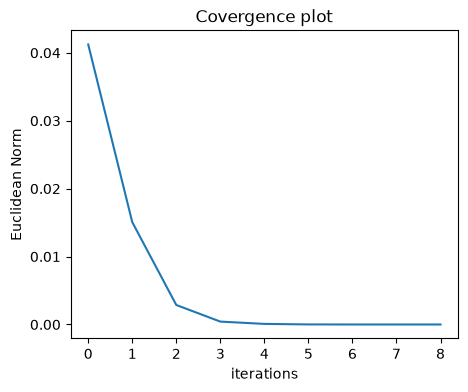


Pagerank importances..
[0.00611187 0.00552979 0.00436562 0.00552979 0.00436562 0.00663575
 0.00436562 0.00436562 0.01002347 0.00552979 0.0077417  0.00727604
 0.00541337 0.00436562 0.00494771 0.00611187 0.00552979 0.00816702
 0.00436562 0.00611187 0.00436562 0.00436562 0.00541337 0.0084402
 0.00832379 0.00436562 0.00494771 0.00611187 0.00611187 0.00960437
 0.00436562 0.00622829 0.00486455 0.00552979 0.00785812 0.00552979
 0.01100137 0.00436562 0.00436562 0.00436562 0.00486455 0.00436562
 0.00486455 0.00934826 0.00611187 0.00436562 0.00436562 0.00436562
 0.00785812 0.00569277 0.00494771 0.00611187 0.00785812 0.00506412
 0.00816702 0.00436562 0.00985118 0.00552979 0.00436562 0.00494771
 0.00552979 0.00506412 0.00436562 0.00436562 0.00486455 0.00486455
 0.01135062 0.00436562 0.00436562 0.00436562 0.00611187 0.00564621
 0.00686858 0.00436562 0.00701992 0.00523875 0.00986048 0.00785812
 0.00653097 0.00785812 0.00816702 0.00436562 0.00552979 0.00552979
 0.00436562 0.00837501 0.00436562 0.004

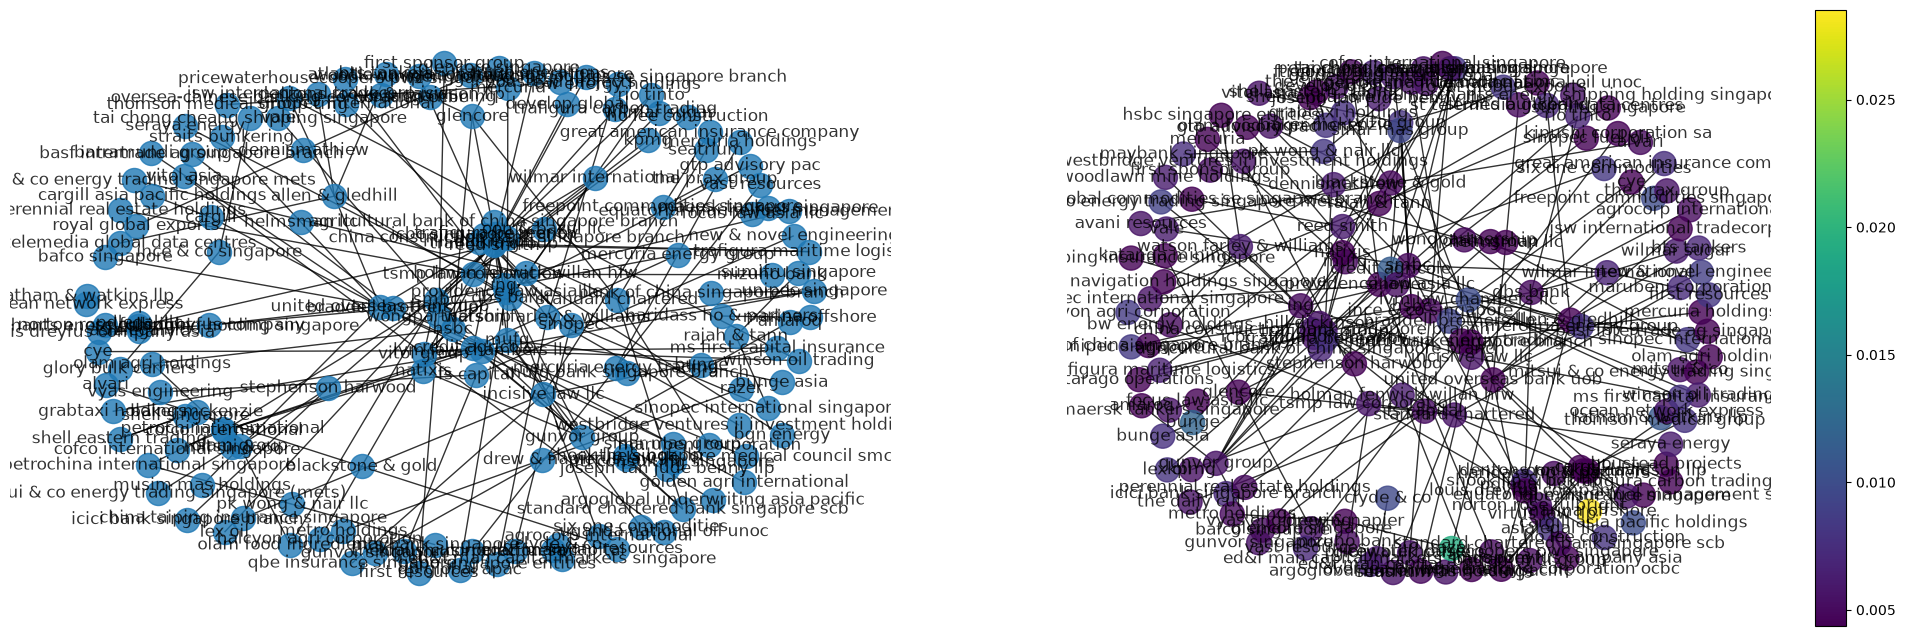

In [33]:
alpha = 0.8
n_iter = 1000
final_probs, int2node = run(DG, alpha, n_iter)

In [34]:
# high value = most important node in pagerank sense = high in-degree
ranked = sorted(enumerate(final_probs), key=lambda x: x[1], reverse=True)
for idx, score in ranked[:10]:
    print(int2node[idx], score)

trafigura group 0.028510416412690108
louis dreyfus company asia 0.01939733309282608
standard chartered bank singapore scb 0.012049116362695973
ed&f man capital markets singapore 0.011350616964020928
shell eastern trading 0.011001366153116207
mercuria energy trading 0.010023467773068173
cofco international singapore 0.009860483320267842
wilmar sugar 0.009851180404655064
petrochina international singapore 0.009604368467333303
unipec singapore 0.009487951761941563


In [ ]:
# basic visualilzation
pos = nx.spring_layout(UG)
nx.draw(UG, pos, with_labels=True, node_color='r')
plt.show()